In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
df_pgcb = pd.read_excel('PGCB_date_power_demand.xlsx')

In [120]:
#exploring PGCB_date_power_demand(EDA)

In [121]:
df_pgcb.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [122]:
df_pgcb.shape

(92650, 15)

In [123]:
df_pgcb.info()

<class 'pandas.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[us]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal                 5351 

In [124]:
df_pgcb.isna().sum() / df_pgcb.shape[0]*100 #percentage of na values

datetime                 0.000000
generation_mw            0.000000
demand_mw                0.000000
load_shedding            0.000000
gas                      0.000000
liquid_fuel              0.000000
coal                     0.000000
hydro                    0.000000
solar                   23.888829
wind                    79.842418
india_bheramara_hvdc     0.000000
india_tripura            0.000000
india_adani             92.079870
nepal                   94.224501
remarks                 93.099838
dtype: float64

In [125]:
df_pgcb = df_pgcb.drop(columns = ['india_adani' , 'nepal' , 'remarks'])
#not dropping solar because data may not be availaible for night hours.
#not dropping wind beause of certain weather conditions.
#other removed coz more than 92% na values therefore uselesss.

In [126]:
df_pgcb.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0


In [127]:
df_pgcb.isna().sum()

datetime                    0
generation_mw               0
demand_mw                   0
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
solar                   22133
wind                    73974
india_bheramara_hvdc        0
india_tripura               0
dtype: int64

In [128]:
df_pgcb['solar'] = df_pgcb['solar'].fillna(0) #value actually 0 for night hours since no power gen through solar

In [129]:
df_pgcb.duplicated(keep=False).sum()

np.int64(288)

In [130]:
df_pgcb[df_pgcb.duplicated(keep=False)] # we see there are duplicate rows we procee to drop these

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura
894,2015-05-26 15:00:00,6421.0,6421,0,3845,1927,90,106,0.0,NaN,453,0
895,2015-05-26 15:00:00,6421.0,6421,0,3845,1927,90,106,0.0,NaN,453,0
1086,2015-06-02 00:00:00,6440.0,6440,0,3866,1841,180,101,0.0,NaN,452,0
1087,2015-06-02 00:00:00,6440.0,6440,0,3866,1841,180,101,0.0,NaN,452,0
1197,2015-06-06 05:00:00,6066.0,6066,0,4252,1151,181,30,0.0,NaN,452,0
1198,2015-06-06 05:00:00,6066.0,6066,0,4252,1151,181,30,0.0,NaN,452,0
1234,2015-06-08 00:00:00,7573.0,7573,0,4389,2483,182,76,0.0,NaN,443,0
1235,2015-06-08 00:00:00,7573.0,7573,0,4389,2483,182,76,0.0,NaN,443,0
2005,2015-07-07 12:00:00,6801.0,6801,0,4512,1633,160,46,0.0,NaN,450,0
2007,2015-07-07 12:00:00,6801.0,6801,0,4512,1633,160,46,0.0,NaN,450,0


In [131]:
df_pgcb = df_pgcb.drop_duplicates()

In [132]:
df_pgcb[df_pgcb.duplicated(subset=['datetime'], keep=False)] #rows with same datetime only(we need to fix this beczuse we have to work with this)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura
55,2015-04-22 21:00:00,5368.0,5368,0,4184,552,160,30,0.0,NaN,442,0
56,2015-04-22 21:00:00,5811.0,5811,0,4158,1021,162,30,0.0,NaN,440,0
90,2015-04-23 00:00:00,5726.0,5726,0,4199,790,158,46,0.0,NaN,433,0
105,2015-04-23 00:00:00,3976.0,3976,0,3116,230,158,30,0.0,NaN,442,0
173,2015-04-27 00:00:00,5459.0,5459,0,4457,363,148,45,0.0,NaN,458,0
178,2015-04-27 00:00:00,4800.0,4800,0,3954,117,166,46,0.0,NaN,458,0
185,2015-04-27 00:00:00,5236.0,5236,0,4417,159,162,46,0.0,NaN,452,0
245,2015-04-30 00:00:00,6889.0,6889,0,4698,1540,157,42,0.0,NaN,452,0
247,2015-04-30 00:00:00,6065.0,6065,0,4239,1187,156,32,0.0,NaN,451,0
259,2015-04-30 00:00:00,5809.0,5809,0,4901,257,154,46,0.0,NaN,451,0


In [133]:
# reason for duplicate datetime can be
#1)00:00:00 could've been recorded as start of new day and end of previous day 
#2)timezones
#3)error while entering data

#we take the average of the other column values and merge it into a single datetime

In [134]:
df_pgcb = df_pgcb.groupby('datetime' , as_index=False).mean()

In [135]:
df_pgcb = df_pgcb.set_index('datetime')

In [136]:
df_pgcb = df_pgcb.sort_index() #sorted datetime 

In [137]:
df_pgcb.head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura
datetime,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0


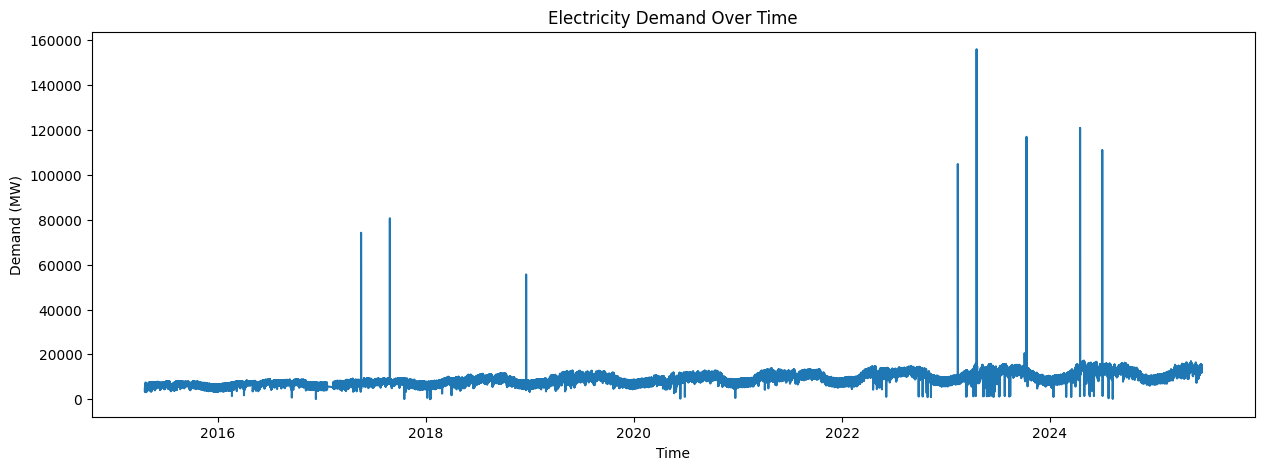

In [138]:
plt.figure(figsize=(15,5))
plt.plot(df_pgcb.index, df_pgcb['demand_mw'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.show()

In [139]:
#we see a slight growth with increasing time 
#we also see sudden spikes , these might be outliers.
#this is more clear by plotting the box plot of demand (we see the outliers clearly)

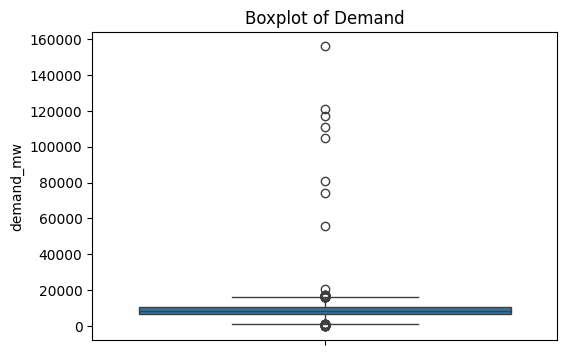

In [140]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_pgcb['demand_mw'])
plt.title("Boxplot of Demand")
plt.show()

In [141]:
Q1 = df_pgcb['demand_mw'].quantile(0.25)
Q3 = df_pgcb['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_pgcb['demand_mw'] = df_pgcb['demand_mw'].clip(lower, upper)

#anything outside the IQR range (25-75 %ile) is an outlier and so we clip the df outside this range.

In [142]:
df_pgcb['hour'] = df_pgcb.index.hour
df_pgcb['dayofweek'] = df_pgcb.index.dayofweek

#we nedd these column as we also have to analyze hourly and weekl demand considering other factors as well.

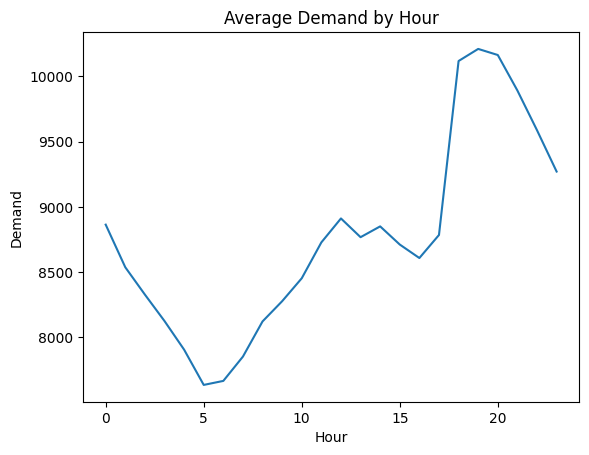

In [143]:
hourly_avg = df_pgcb.groupby('hour')['demand_mw'].mean()

plt.plot(hourly_avg)
plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Demand")
plt.show()

In [144]:
## we observe that the peaks hours are 5 am when the demand is lowest and 8pm when the demand is highest for the day" 

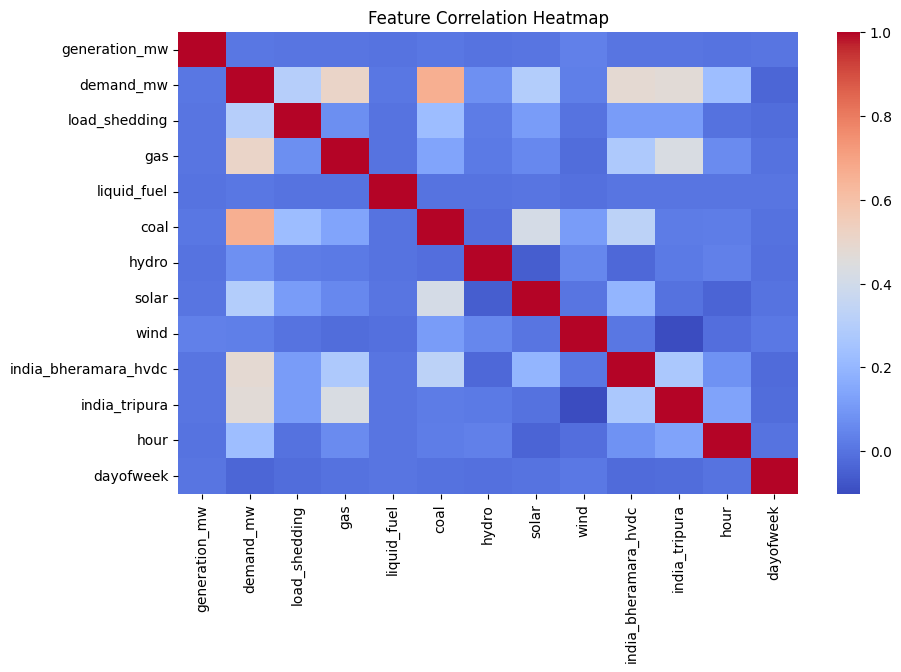

In [145]:
plt.figure(figsize=(10,6))
corr = df_pgcb.corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [146]:
## we observe that gas and coal have relatively significant correlation with demand

In [147]:
## our PGCB dataset is now ready now we use the other two datasets

In [148]:
#latitude = 23.7961
#longitude = 90.3805
#elevation = 9
#utc_offset_seconds = 21600
#timezone = Asia/Dhaka
#timezone_abbreviation = GMT+6

df_weather = pd.read_excel("weather_data.xlsx", skiprows=3)
df_weather.columns = df_weather.columns.str.strip()

df_weather = df_weather.drop(columns=['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8'], errors='ignore')

In [149]:
df_weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [150]:
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 107304 entries, 0 to 107303
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   time                            107304 non-null  datetime64[us]
 1   temperature_2m (°C)             107304 non-null  float64       
 2   relative_humidity_2m (%)        107304 non-null  int64         
 3   apparent_temperature (°C)       107304 non-null  float64       
 4   precipitation (mm)              107304 non-null  float64       
 5   dew_point_2m (°C)               107304 non-null  float64       
 6   soil_temperature_0_to_7cm (°C)  107304 non-null  float64       
 7   wind_direction_10m (°)          107304 non-null  int64         
 8   cloud_cover (%)                 107304 non-null  int64         
 9   sunshine_duration (s)           107304 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(3)
memory usage: 8.2 MB


In [151]:
df_weather.isna().sum()

time                              0
temperature_2m (°C)               0
relative_humidity_2m (%)          0
apparent_temperature (°C)         0
precipitation (mm)                0
dew_point_2m (°C)                 0
soil_temperature_0_to_7cm (°C)    0
wind_direction_10m (°)            0
cloud_cover (%)                   0
sunshine_duration (s)             0
dtype: int64

In [152]:
df_weather.duplicated(['time']).sum()

np.int64(0)

In [153]:
#no duplicates exist so we can proceed to merge these datasets

In [154]:
df_weather.rename(columns = {'time' : 'datetime'} , inplace = True)

In [155]:
df = df_pgcb.merge(df_weather, on='datetime', how='left')

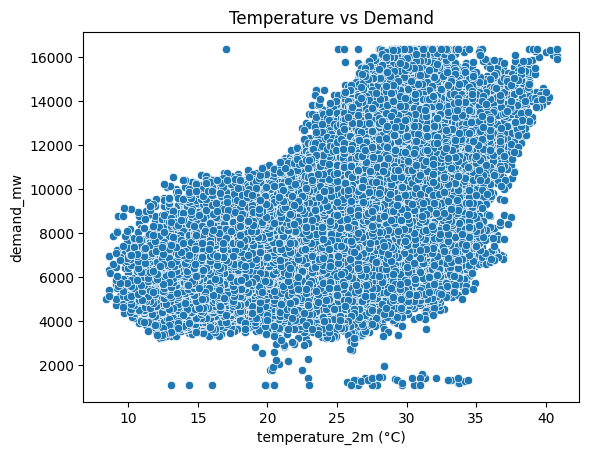

In [156]:
sns.scatterplot(x=df['temperature_2m (°C)'], y=df['demand_mw'])
plt.title("Temperature vs Demand")
plt.show()

In [157]:
#High demand at extreme temps (hot/cold)

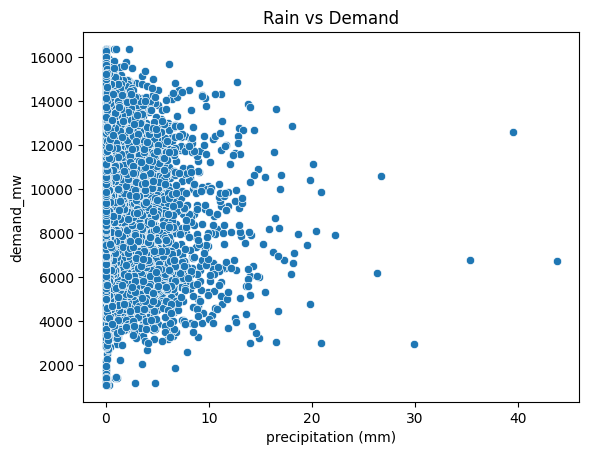

In [158]:
sns.scatterplot(x=df['precipitation (mm)'], y=df['demand_mw'])
plt.title("Rain vs Demand")
plt.show()

In [159]:
#Rainy days -> different consumption behavior

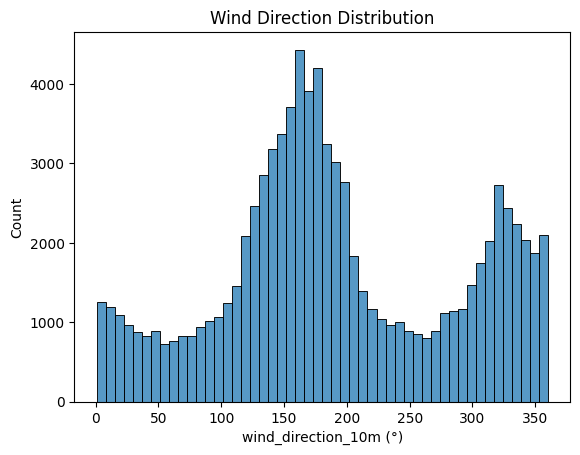

In [160]:
sns.histplot(df['wind_direction_10m (°)'], bins=50)
plt.title("Wind Direction Distribution")
plt.show()

#just for exploration

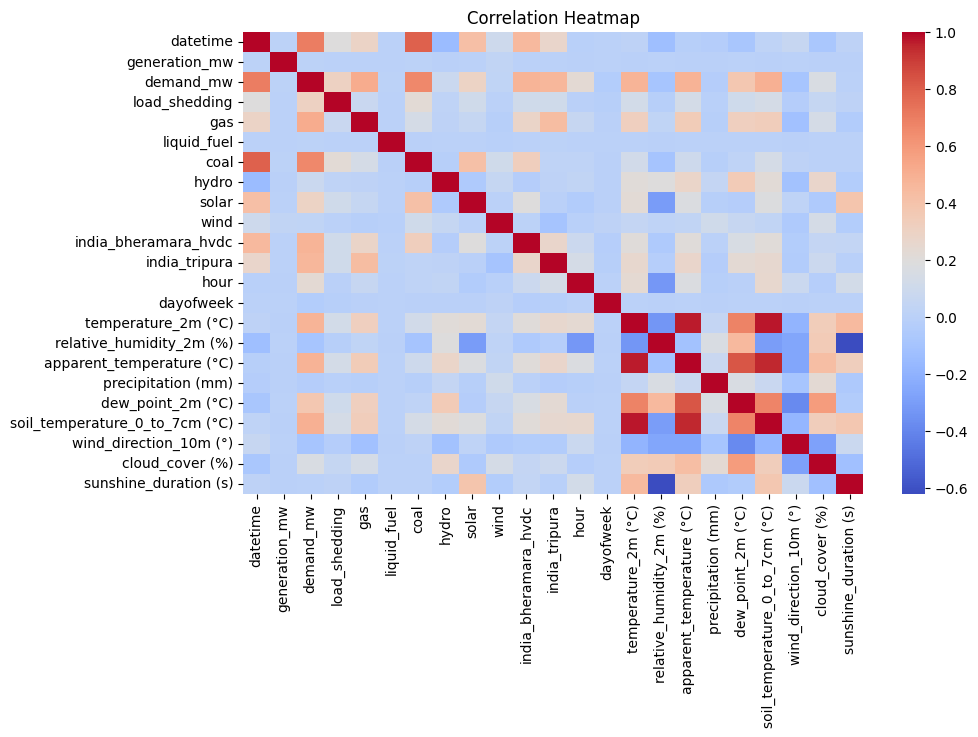

In [161]:
plt.figure(figsize=(10,6))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [162]:
#In the heatmap we observe that the weather conditions like apparent temp , soil temp , and dew point are also significantly
#coorelated with the demand

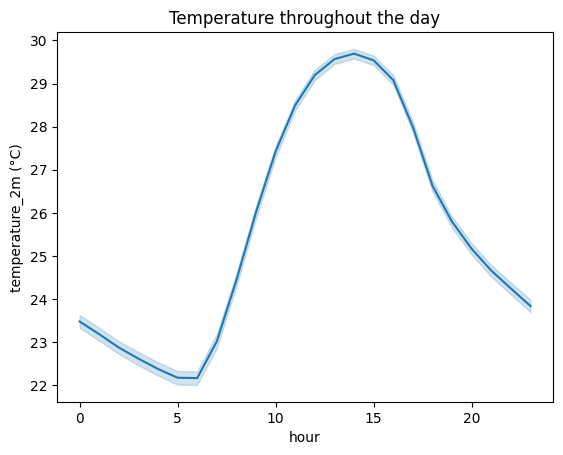

In [163]:
sns.lineplot(x='hour', y='temperature_2m (°C)', data=df)
plt.title("Temperature throughout the day")
plt.show()

In [164]:
## the peak hours for high temp is around 3 pm
#this is useful because temp is correlated with the target variable

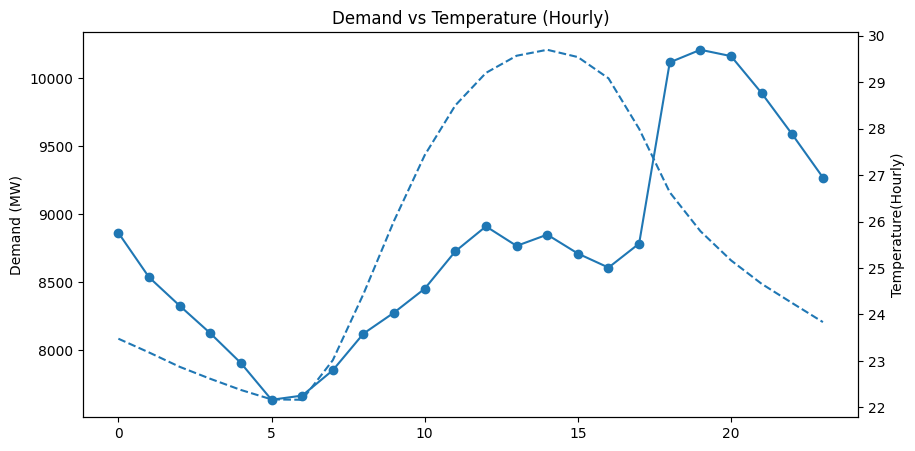

In [165]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Demand (left axis)
ax1.plot(df.groupby('hour')['demand_mw'].mean(), label='Demand', marker='o')
ax1.set_ylabel('Demand (MW)')

# Temperature (right axis)
ax2 = ax1.twinx()
ax2.plot(df.groupby('hour')['temperature_2m (°C)'].mean(), linestyle='--', label='Temperature')
ax2.set_ylabel('Temperature (°C)')

plt.title("Demand vs Temperature (Hourly)")
plt.xlabel("Hour")
plt.ylabel("Temperature(Hourly)")

plt.show()

In [166]:
#the analysis for weather parameters is done now we move to the economy dataset

In [167]:
df_econ = pd.read_csv("economic_full_1.csv")
pd.set_option('display.max_columns', None)
df_econ.head()

,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000,45.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.000000,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,NaN,47.263683,NaN,44.776119,NaN,37.313435,31.840796,27.884615,30.288462,32.211540,31.250000,33.173077,38.388626,36.966824,36.150234,34.741783,34.741783,32.019703,30.049261,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.891353,31.881229,25.356398,28.035955,22.818176,23.092774,14.354791,16.347633,16.710434,14.932957,12.515757,13.124788,12.929416,12.721805,12.948579,10.370807,10.429827,9.762589,13.152802,14.98295,35.857466,34.054101,36.568027,35.407735,32.180526,29.503600,26.777458,14.821547,16.835488,16.295788,9.983813,8.168923,10.683500,15.170216,14.217416,19.455311,27.917838,32.545223,23.905528,23.938111,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.583179,58.179809,67.113239,62.001316,67.936763,70.528074,70.703822,61.603364,66.002299,73.775462,79.783370,81.344349,81.204968,80.323887,80.588643,83.564321,83.186992,83.416202,81.624655,79.58021,43.536648,37.766478,37.020636,38.190707,44.215626,46.239064,52.655580,67.340668,65.136817,70.824661,77.597275,81.291891,78.751694,72.224917,75.356085,69.732655,59.189573,54.908579,62.323794,62.897128,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [168]:
df_econ.info()

<class 'pandas.DataFrame'>
RangeIndex: 1516 entries, 0 to 1515
Data columns (total 69 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    1516 non-null   str    
 1   Indicator Name  1516 non-null   str    
 2   Indicator Code  1516 non-null   str    
 3   1960            176 non-null    float64
 4   1961            217 non-null    float64
 5   1962            210 non-null    float64
 6   1963            210 non-null    float64
 7   1964            210 non-null    float64
 8   1965            212 non-null    float64
 9   1966            210 non-null    float64
 10  1967            215 non-null    float64
 11  1968            215 non-null    float64
 12  1969            215 non-null    float64
 13  1970            295 non-null    float64
 14  1971            287 non-null    float64
 15  1972            348 non-null    float64
 16  1973            425 non-null    float64
 17  1974            424 non-null    float64
 18 

In [169]:
pd.set_option('display.max_rows', None)
df_econ.isna().sum() / df_econ.shape[0]*100

Country Name       0.000000
Indicator Name     0.000000
Indicator Code     0.000000
1960              88.390501
1961              85.686016
1962              86.147757
1963              86.147757
1964              86.147757
1965              86.015831
1966              86.147757
1967              85.817942
1968              85.817942
1969              85.817942
1970              80.540897
1971              81.068602
1972              77.044855
1973              71.965699
1974              72.031662
1975              72.625330
1976              66.094987
1977              65.501319
1978              66.424802
1979              66.160950
1980              64.116095
1981              61.345646
1982              65.369393
1983              62.203166
1984              62.269129
1985              60.751979
1986              61.213720
1987              62.730871
1988              62.071240
1989              60.554090
1990              55.408971
1991              53.496042
1992              56

In [170]:
df_econ['Indicator Name'] = df_econ['Indicator Name'].str.strip()

In [171]:
#all unique indicators
print(df_econ['Indicator Name'].unique())
print(len(df_econ['Indicator Name'].unique()))

<StringArray>
[                                                                           'Intentional homicides, male (per 100,000 male)',
                                                                                  'Battle-related deaths (number of people)',
                                                                                 'Voice and Accountability: Percentile Rank',
                                                                      'Transport services (% of commercial service exports)',
                                             'Computer, communications and other services (% of commercial service exports)',
                                   'Merchandise exports by the reporting economy, residual (% of total merchandise exports)',
 'Merchandise exports to low- and middle-income economies in Latin America & the Caribbean (% of total merchandise exports)',
                                             'Merchandise exports to high-income economies (% of total m

In [172]:
# See all unique countries
print(df_econ['Country Name'].unique())

<StringArray>
['X']
Length: 1, dtype: str


In [173]:
#these is only one country 'X' so the column Country Name is Basically useless.
df_econ = df_econ.drop(columns=['Country Name'])

In [174]:
#The data is in wide format but we need to make it into long format to make our work with the earlier dataframe easier.

df_econ_long = df_econ.melt(
    id_vars=['Indicator Name', 'Indicator Code'],
    var_name='year',
    value_name='value'
)

df_econ_long['year'] = df_econ_long['year'].astype(int)

In [175]:
df_econ_long.head()

,Indicator Name,Indicator Code,year,value
0,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,1960,NaN
1,Battle-related deaths (number of people),VC.BTL.DETH,1960,NaN
2,Voice and Accountability: Percentile Rank,VA.PER.RNK,1960,NaN
3,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,1960,NaN
4,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,1960,NaN


In [176]:
df_econ_pivot = df_econ_long.pivot(
    index='year',
    columns='Indicator Name',
    values='value'
).reset_index()

In [177]:
df_econ_pivot.head()

Indicator Name  year  \
0               1960   
1               1961   
2               1962   
3               1963   
4               1964   

Indicator Name  ARI treatment (% of children under 5 taken to a health provider)  \
0                                                             NaN                  
1                                                             NaN                  
2                                                             NaN                  
3                                                             NaN                  
4                                                             NaN                  

Indicator Name  Access to clean fuels and technologies for cooking (% of population)  \
0                                                             NaN                      
1                                                             NaN                      
2                                                             NaN                      
3                                                             NaN                      
4                                                             NaN                      

Indicator Name  Access to clean fuels and technologies for cooking, rural (% of rural population)  \
0                                                             NaN                                   
1                                                             NaN                                   
2                                                             NaN                                   
3                                                             NaN                                   
4                                                             NaN                                   

Indicator Name  Access to clean fuels and technologies for cooking, urban (% of urban population)  \
0                                                             NaN                                   
1                                                             NaN                                   
2                                                             NaN                                   
3                                                             NaN                                   
4                                                             NaN                                   

Indicator Name  Access to electricity (% of population)  \
0                                                   NaN   
1                                                   NaN   
2                                                   NaN   
3                                                   NaN   
4                                                   NaN   

Indicator Name  Access to electricity, rural (% of rural population)  \
0                                                             NaN      
1                                                             NaN      
2                                                             NaN      
3                                                             NaN      
4                                                             NaN      

Indicator Name  Access to electricity, urban (% of urban population)  \
0                                                             NaN      
1                                                             NaN      
2                                                             NaN      
3                                                             NaN      
4                                                             NaN      

Indicator Name  Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)  \
0                                                             NaN                                                                 
1                                                             NaN                                                           

In [178]:
df_econ_pivot.columns

Index(['year',
       'ARI treatment (% of children under 5 taken to a health provider)',
       'Access to clean fuels and technologies for cooking (% of population)',
       'Access to clean fuels and technologies for cooking, rural (% of rural population)',
       'Access to clean fuels and technologies for cooking, urban (% of urban population)',
       'Access to electricity (% of population)',
       'Access to electricity, rural (% of rural population)',
       'Access to electricity, urban (% of urban population)',
       'Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)',
       'Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)',
       ...
       'Women who believe a husband is justified in beating his wife (any of five reasons) (%)',
       'Women who believe a husband is justified in beating his wife when she argues with him (%)',
       'Wom

In [179]:
useful_indicators = [
    # Direct energy indicators
    'Electric power consumption (kWh per capita)',
    'Electricity production from renewable sources, excluding hydroelectric (% of total)',
    'Electricity production from coal sources (% of total)',
    'Electricity production from natural gas sources (% of total)',
    'Electricity production from hydroelectric sources (% of total)',
    'Electric power transmission and distribution losses (% of output)',
    
    # Economic activity
    'GDP (current US$)',
    'GDP per capita (current US$)',
    'GDP growth (annual %)',
    'Manufacturing, value added (% of GDP)',
    'Industry (including construction), value added (% of GDP)',
    'Gross fixed capital formation (% of GDP)',
    
    # Population & development
    'Population, total',
    'Urban population (% of total population)',
    'Access to electricity (% of population)',
    
    # Trade & fuel prices
    'Fuel exports (% of merchandise exports)',
    'Fuel imports (% of merchandise imports)',
    'High-technology exports (% of manufactured exports)',
    
    # Inflation & money (proxy for economic cycles)
    'Inflation, consumer prices (annual %)',
    'Real interest rate (%)',
    
    # Climate/energy policy
    'Renewable energy consumption (% of total final energy consumption)',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
    'CO2 emissions (metric tons per capita)'
]

In [180]:
#GDP per capita is redundant with GDP + population
#Manufacturing % overlaps with industry
#All fuel trade indicators is a weak link to demand
#CO₂ is an outcome, not driver
#High-tech exports are irrelevant for grid load
#Too many energy mix variables -> multicollinearity

In [181]:
final_indicators = [
    # Core demand drivers
    'Electric power consumption (kWh per capita)',
    'Population, total',
    'Access to electricity (% of population)',
    
    # Economic scale & growth
    'GDP (current US$)',
    'GDP growth (annual %)',
    
    # Industrial activity
    'Industry (including construction), value added (% of GDP)',
    
    # System efficiency / losses
    'Electric power transmission and distribution losses (% of output)',
    
    # Energy structure (keep ONLY 1–2, not all)
    'Electricity production from natural gas sources (% of total)',
    'Electricity production from hydroelectric sources (% of total)',
    
    # Macro condition
    'Inflation, consumer prices (annual %)'
]

In [182]:
df_econ_long = df_econ_long[
    df_econ_long['Indicator Name'].isin(final_indicators)
]

In [1]:
#We clip our columns to only the inportant final indicators

In [183]:
df_econ_pivot = df_econ_long.pivot(
    index='year',
    columns='Indicator Name',
    values='value'
).reset_index()

In [2]:
#we made the row index as the years and the columns as the indicators

In [184]:
df_econ_pivot = df_econ_pivot.sort_values('year')

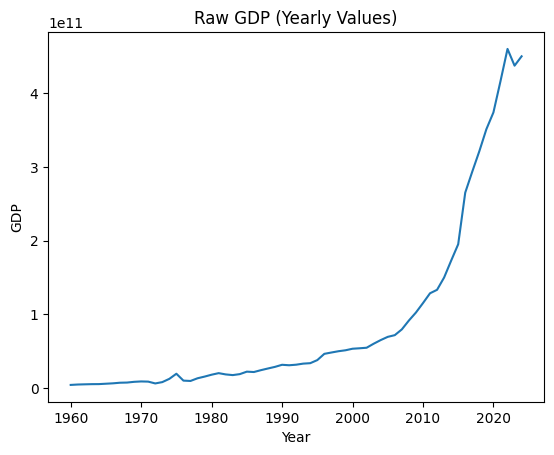

In [185]:
plt.figure()
plt.plot(df_econ_pivot['year'], df_econ_pivot['GDP (current US$)'])
plt.title('Raw GDP (Yearly Values)')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.show()

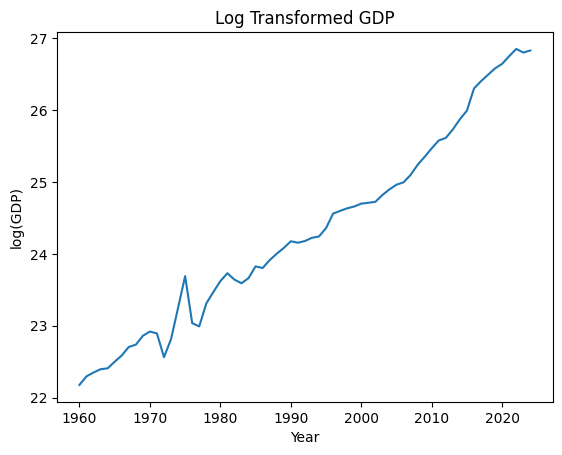

In [186]:
df_econ_pivot['gdp_log'] = np.log1p(df_econ_pivot['GDP (current US$)'])

plt.figure()
plt.plot(df_econ_pivot['year'], df_econ_pivot['gdp_log'])
plt.title('Log Transformed GDP')
plt.xlabel('Year')
plt.ylabel('log(GDP)')
plt.show()

In [187]:
#log transformation makes the relation of GDP and Tears linear thereby easy to intrepret for the 

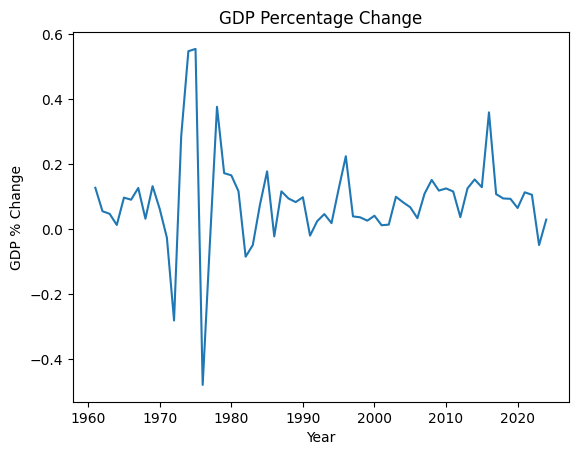

In [188]:
df_econ_pivot['gdp_pct_change'] = df_econ_pivot['GDP (current US$)'].pct_change()

plt.figure()
plt.plot(df_econ_pivot['year'], df_econ_pivot['gdp_pct_change'])
plt.title('GDP Percentage Change')
plt.xlabel('Year')
plt.ylabel('GDP % Change')
plt.show()

In [189]:
# log transforms
df_econ_pivot['pop_log'] = np.log1p(df_econ_pivot['Population, total'])

# growth / change features
df_econ_pivot['pop_pct_change'] = df_econ_pivot['Population, total'].pct_change()

#lag macro signals (important to avoid leakage).
#For each year we use the previous year’s GDP growth instead of the current year’s.
#because we want to predict demand at time t+1 using info up to time t.
df_econ_pivot['gdp_growth_lag1'] = df_econ_pivot['GDP growth (annual %)'].shift(1)

In [191]:
df['year'] = df['datetime'].dt.year

df = df.merge(df_econ_pivot, on='year', how='left')

In [3]:
#Now we have a merged dataframe with important fearures from all the 3 datasets with time as the common index

In [192]:
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,hour,dayofweek,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),year,Access to electricity (% of population),Electric power consumption (kWh per capita),Electric power transmission and distribution losses (% of output),Electricity production from hydroelectric sources (% of total),Electricity production from natural gas sources (% of total),GDP (current US$),GDP growth (annual %),"Industry (including construction), value added (% of GDP)","Inflation, consumer prices (annual %)","Population, total",gdp_log,gdp_pct_change,pop_log,pop_pct_change,gdp_growth_lag1
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0,6,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1,6,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059
2,2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,2,6,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059
3,2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,3,6,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059
4,2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,4,6,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059


In [193]:
df = df.sort_values('datetime')

df['target'] = df['demand_mw'].shift(-1)
#Use current information (time t) to predict demand at next hour (t+1)
#shift(-1) moves demand up, so each row sees the next hour’s demand

In [194]:
# short-term
df['lag_1'] = df['demand_mw'].shift(1)
df['lag_2'] = df['demand_mw'].shift(2)
df['lag_3'] = df['demand_mw'].shift(3)

df['lag_24'] = df['demand_mw'].shift(24)
df['lag_168'] = df['demand_mw'].shift(168)

#lag_1 = last hour demand
#lag_24 = same hour yesterday
#lag_168 = same hour last week

In [195]:
df['rolling_mean_3'] = df['demand_mw'].shift(1).rolling(3).mean()
df['rolling_mean_24'] = df['demand_mw'].shift(1).rolling(24).mean()
df['rolling_std_24'] = df['demand_mw'].shift(1).rolling(24).std()

#rolling_mean_24 = average demand in last 24 hours
#rolling_std_24 = variability in last 24 hours
#Used shift(1) coz we are using only past data so no cheating.

In [196]:
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month

df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

#Hour = daily cycle
#Day of week = weekday vs weekend behavior
#Month = seasonal effects
#Because demand follows strong periodic patterns

In [197]:
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,hour,dayofweek,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),year,Access to electricity (% of population),Electric power consumption (kWh per capita),Electric power transmission and distribution losses (% of output),Electricity production from hydroelectric sources (% of total),Electricity production from natural gas sources (% of total),GDP (current US$),GDP growth (annual %),"Industry (including construction), value added (% of GDP)","Inflation, consumer prices (annual %)","Population, total",gdp_log,gdp_pct_change,pop_log,pop_pct_change,gdp_growth_lag1,target,lag_1,lag_2,lag_3,lag_24,lag_168,rolling_mean_3,rolling_mean_24,rolling_std_24,month,is_weekend
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0,6,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059,3612.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1,6,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059,3727.0,4821.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1
2,2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,2,6,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059,3632.0,3612.0,4821.0,NaN,NaN,NaN,NaN,NaN,NaN,4,1
3,2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,3,6,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059,3641.0,3727.0,3612.0,4821.0,NaN,NaN,4053.333333,NaN,NaN,4,1
4,2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,4,6,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0,2015,74.0,348.932681,11.991373,1.010935,80.568145,1.951470e+11,6.55264,26.831395,6.19428,159383179.0,25.997019,0.128755,18.886822,0.008978,6.061059,3283.0,3632.0,3727.0,3612.0,NaN,NaN,3657.000000,NaN,NaN,4,1


In [198]:
df.shape

(92218, 50)

In [199]:
df['datetime'].dtype

dtype('<M8[us]')

In [201]:
print(df['datetime'].min(), df['datetime'].max())

2015-04-19 00:00:00 2025-06-17 12:00:00


In [202]:
df = df.dropna(subset=['target'])

In [221]:
train = df[df['datetime'] < '2023-01-01']
test  = df[df['datetime'] >= '2023-01-01']

# features & target
x_train = train.drop(columns=['target', 'datetime'])
y_train = train['target']

x_test = test.drop(columns=['target', 'datetime'])
y_test = test['target']

print("Train size:", x_train.shape)
print("Test size:", x_test.shape)

Train size: (69794, 48)
Test size: (22423, 48)


In [222]:
# We drop 'target' because it is the variable we are trying to predict (to avoid data leakage).
# We drop 'datetime' because ML models cannot directly interpret timestamps;
# instead, we have already extracted useful time-based features like hour, dayofweek, etc.
# The remaining columns form the feature set (X) used by the model.

In [223]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [224]:
y_pred = model.predict(x_test)

In [225]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape * 100)

MAPE: 4.373319598651213


In [226]:
#MAPE Score : 4.37%
#Now we try XGBoost and see if the mape improves more

In [227]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [228]:
y_pred = model.predict(x_test)

In [229]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape * 100)

MAPE: 4.598456359417812


In [230]:
#We see that the random forest model is slightly better than XG BOost so we'll stick to that

In [231]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [232]:
y_pred = model.predict(x_test)

In [233]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape * 100)

MAPE: 4.373319598651212


In [234]:
#Now we see what were the important features

In [235]:
importance = pd.Series(model.feature_importances_, index=x_train.columns)
importance = importance.sort_values(ascending=False)

# print top 10
print("Top 10 Features:\n")
print(importance.head(10))

Top 10 Features:

demand_mw                0.720351
generation_mw            0.246538
lag_24                   0.011618
hour                     0.008028
sunshine_duration (s)    0.002623
lag_3                    0.001477
solar                    0.000991
lag_1                    0.000888
rolling_mean_3           0.000867
lag_2                    0.000856
dtype: float64


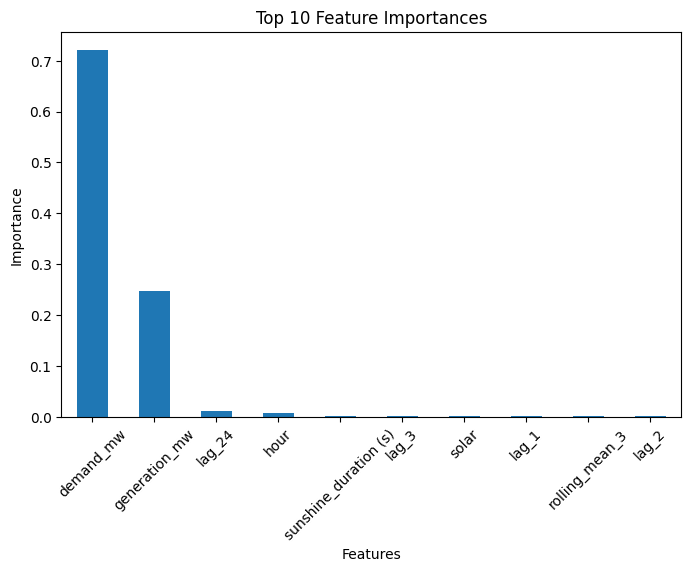

In [236]:
plt.figure(figsize=(8,5))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.show()

In [237]:
#our model is heavily relying on current demand (demand_mw)
#we want to predict next hour demand (t+1) using info at time t
#but our model is basically learning next hour demand ~= current demand

#so we decide to remove demand_mw from x_train/test to make the model more realistic
#this will increase the mape but will be more genuine

In [238]:
train = df[df['datetime'] < '2023-01-01']
test  = df[df['datetime'] >= '2023-01-01']

# features & target
x_train = train.drop(columns=['target', 'datetime' , 'demand_mw'])
y_train = train['target']

x_test = test.drop(columns=['target', 'datetime' , 'demand_mw'])
y_test = test['target']

print("Train size:", x_train.shape)
print("Test size:", x_test.shape)

Train size: (69794, 47)
Test size: (22423, 47)


In [239]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [241]:
y_pred = model.predict(x_test)

In [242]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape * 100)

MAPE: 4.295310465918384


In [243]:
importance = pd.Series(model.feature_importances_, index=x_train.columns)
importance = importance.sort_values(ascending=False)

# print top 10
print("Top 10 Features:\n")
print(importance.head(10))

Top 10 Features:

generation_mw            0.953692
lag_24                   0.020861
hour                     0.007665
load_shedding            0.002906
sunshine_duration (s)    0.002552
lag_1                    0.002082
lag_3                    0.001487
solar                    0.000928
lag_2                    0.000877
rolling_mean_24          0.000852
dtype: float64


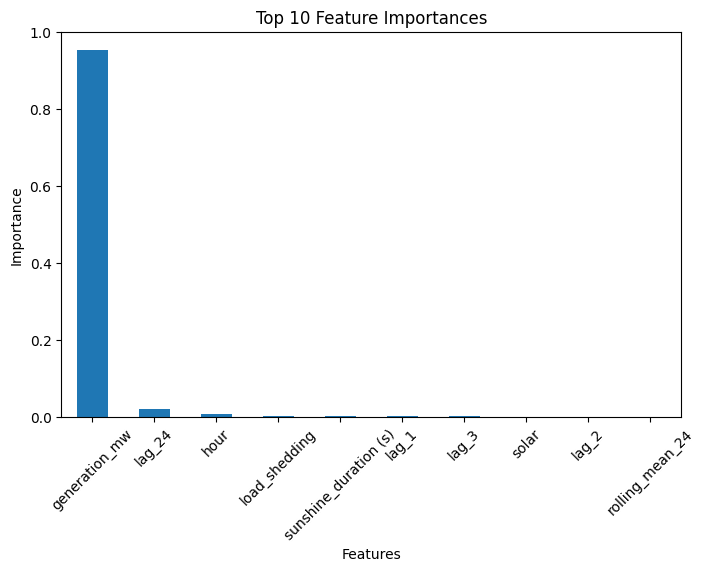

In [244]:
plt.figure(figsize=(8,5))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.show()

In [245]:
#The same problem happens with generation_mw as well
#our model is almost completly relying on tome = t's generation to predict the t+1's demand (bias)
#so we remove generation_mw as well

In [246]:
train = df[df['datetime'] < '2023-01-01']
test  = df[df['datetime'] >= '2023-01-01']

# features & target
x_train = train.drop(columns=['target', 'datetime' , 'demand_mw' , 'generation_mw'])
y_train = train['target']

x_test = test.drop(columns=['target', 'datetime' , 'demand_mw' , 'generation_mw'])
y_test = test['target']

print("Train size:", x_train.shape)
print("Test size:", x_test.shape)

Train size: (69794, 46)
Test size: (22423, 46)


In [247]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [248]:
y_pred = model.predict(x_test)

In [249]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape * 100)

MAPE: 7.59093679280254


In [250]:
importance = pd.Series(model.feature_importances_, index=x_train.columns)
importance = importance.sort_values(ascending=False)

# print top 10
print("Top 10 Features:\n")
print(importance.head(10))

Top 10 Features:

lag_1                    0.789501
lag_24                   0.162774
hour                     0.011449
liquid_fuel              0.009453
sunshine_duration (s)    0.004995
gas                      0.003968
temperature_2m (°C)      0.002446
lag_3                    0.002220
india_tripura            0.001703
solar                    0.001573
dtype: float64


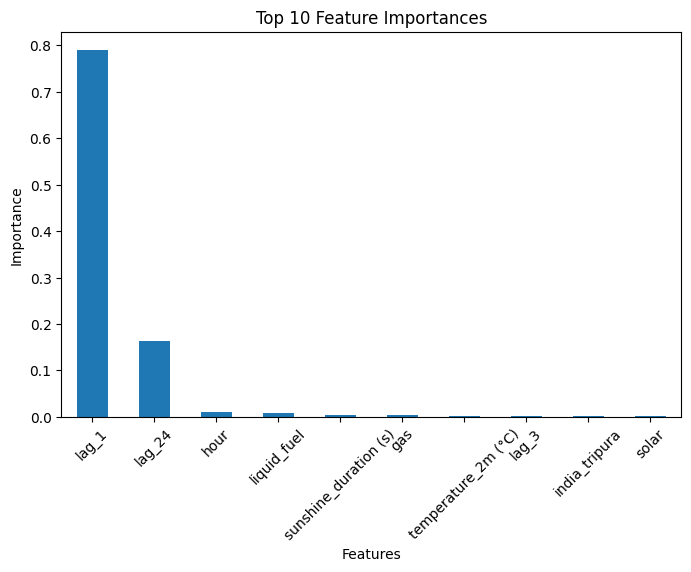

In [251]:
plt.figure(figsize=(8,5))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.show()

In [252]:
#This looks good
#Our model is now relying on our engineered features without any shortcuts
#This is also the reason why the mape increased

In [253]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [254]:
y_pred = model.predict(x_test)

In [255]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape * 100)

MAPE: 10.71616245671782


In [256]:
#Still Random Forest model gives the best MAPE score so we stay with it

In [258]:
#So final MAPE score : 7.59093679280254%

#We used the Random Forest Regressor Model 
#lag_1                    0.789501
#lag_24                   0.162774
#hour                     0.011449
#liquid_fuel              0.009453
#sunshine_duration (s)    0.004995
#gas                      0.003968
#temperature_2m (°C)      0.002446
#lag_3                    0.002220
#india_tripura            0.001703
#solar 

#the above aare the to 10 features for our model